# q1

In [ ]:
import graph_tool.all as gt
from graph_tool.all import Graph # again, doesnt seem to work unless i import it directly
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as spio
import json

# extracting LCC
g_full = gt.collection.ns['polblogs']
g = gt.extract_largest_component(g_full, directed=False)

# obtaining partitions
deg_corr = gt.minimize_blockmodel_dl(
    g, 
    state_args=dict(deg_corr=True), 
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

non_deg_corr = gt.minimize_blockmodel_dl(
    g, 
    state_args=dict(deg_corr=False), 
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

# PropertyMaps for visualization
dc_comms = deg_corr.get_blocks()
ndc_comms = non_deg_corr.get_blocks()

pos = gt.sfdp_layout(g)
# visualization function
def visualize(g, comms, fpath):
    gt.graph_draw(g,
                  pos=pos,
                  vertex_fill_color=comms,
                  inline=True,
                  output=fpath)
    
visualize(g, dc_comms, r'./imgs/communities_deg_corr.png')
visualize(g, ndc_comms, r'./imgs/communities_non_deg_corr.png')

Degree-corrected: 63427.543763773785
Non-degree-corrected: 83131.51079688838


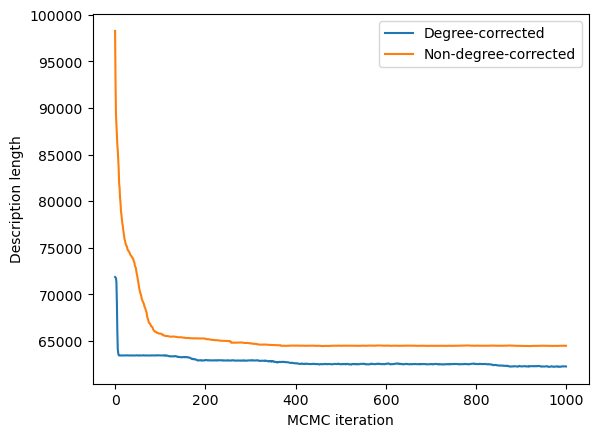

In [12]:
# desc length pt i
print(f"Degree-corrected: {deg_corr.entropy()}")
print(f"Non-degree-corrected: {non_deg_corr.entropy()}")

# init states
state_dc = gt.BlockState(g, B=2, deg_corr=True)
state_ndc = gt.BlockState(g, B=2, deg_corr=False)

def sweep(state):
    dls = []
    for i in range(1000):
        state.mcmc_sweep(niter=1)
        dls.append(state.entropy())
    return dls

dls_dc = sweep(state_dc)
dls_ndc = sweep(state_ndc)

plt.plot(dls_dc, label="Degree-corrected")
plt.plot(dls_ndc, label="Non-degree-corrected")
plt.xlabel("MCMC iteration")
plt.ylabel("Description length")
plt.legend()
plt.savefig(r'./imgs/1bii.png')

# q2

In [99]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import math
import itertools
import osmnx as ox
from scipy.cluster.hierarchy import linkage, leaves_list

In [3]:
G = nx.karate_club_graph()
N = len(G.nodes())

X = np.zeros((N, 6)) # init empty array for later
feature_names = ['Degree', 'Clustering', 'Closeness', 'PageRank', 'Tenure', 'Height'] # specify feature names

# get 4 network attributes as dicts
degree = dict(G.degree())
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

# --- create synthetic attributes ---

# defining mean and std dev (1 per attribute per club)
mean_tenure_hi = 360
std_tenure_hi = 55
mean_height_hi = 175
std_height_hi = 7

mean_tenure_o = 290
std_tenure_o = 73
mean_height_o = 181
std_height_o = 8

np.random.seed(21) # ensure values don't change between runs

# collecting samples
tenure = {}
height = {}
for node, club in G.nodes(data='club'):
    if club == 'Mr. Hi':
        tenure[node] = np.random.normal(mean_tenure_hi, std_tenure_hi)
        height[node] = np.random.normal(mean_height_hi, std_height_hi)
    else:
        tenure[node] = np.random.normal(mean_tenure_o, std_tenure_o)
        height[node] = np.random.normal(mean_height_o, std_height_o)

# === Random Forest Classifier ===

# filling in feature matrix
for i in range(N):
    X[i, 0] = degree[i]
    X[i, 1] = clustering[i]
    X[i, 2] = closeness[i]
    X[i, 3] = pagerank[i]
    X[i, 4] = tenure[i]
    X[i, 5] = height[i]

# building out train/test splits
y = [G.nodes[i]['club'] for i in range(N)] # bringing in attribute for stratification/prediction
splits = []
for seed in range(50): # new seed each time
    split = {}
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    split[seed] = (X_train, X_test, y_train, y_test) # dict so i can ref seed for confusion matrix
    splits.append(split)

# init lists and classifier
accuracy_scores = []
f1_scores = []
importances = []
classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# fitting and recording
for split in splits:
    for seed, result in split.items():
        X_train, X_test, y_train, y_test = result # unpacking tuple

        # fitting model and getting predictions
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)

        # computing accuracy and f1
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        accuracy_scores.append(acc)
        f1_scores.append(f1)

        # record importance vector, map to names
        importance = pd.Series(classifier.feature_importances_, index=feature_names)
        importances.append(importance)

        # getting confusion matrix for single split
        if seed == 1:
            cm_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# mean and std dev for scores
mean_acc = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)
std_acc = np.std(accuracy_scores)
std_f1 = np.std(f1_scores)

# avg importance vector + sort in descending order
agg_importance = np.mean(importances, axis=0)
top5 = pd.Series(agg_importance, index=feature_names).sort_values(ascending=False).head(5)

# report results
print(f"Mean Accuracy: {mean_acc:.2f}\nMean F1: {mean_f1:.2f}\nStd Accuracy: {std_acc:.2f}\nStd F1: {std_f1:.2f}")
print(cm_df)
print(f"Top 5 Features by Importance: {top5}")

# === Robustness Test ===

# clean separation
print('\n=====================================\n')

# increasing noise (50%)
d = 3
std_tenure_hi = std_tenure_hi * d
std_height_hi = std_height_hi * d
std_tenure_o = std_tenure_o * d
std_height_o = std_height_o * d

# --- same as before ---

# collecting samples
tenure = {}
height = {}
for node, club in G.nodes(data='club'):
    if club == 'Mr. Hi':
        tenure[node] = np.random.normal(mean_tenure_hi, std_tenure_hi)
        height[node] = np.random.normal(mean_height_hi, std_height_hi)
    else:
        tenure[node] = np.random.normal(mean_tenure_o, std_tenure_o)
        height[node] = np.random.normal(mean_height_o, std_height_o)

# filling in feature matrix
for i in range(N):
    X[i, 0] = degree[i]
    X[i, 1] = clustering[i]
    X[i, 2] = closeness[i]
    X[i, 3] = pagerank[i]
    X[i, 4] = tenure[i]
    X[i, 5] = height[i]

# building out train/test splits
y = [G.nodes[i]['club'] for i in range(N)] # bringing in attribute for stratification/prediction
splits = []
for seed in range(50): # new seed each time
    split = {}
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    split[seed] = (X_train, X_test, y_train, y_test)
    splits.append(split)

# resetting lists
accuracy_scores = []
f1_scores = []
importances = []

# fitting and recording
for split in splits:
    for seed, result in split.items():
        X_train, X_test, y_train, y_test = result # unpacking tuple

        # fitting model and getting predictions
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)

        # computing accuracy and f1
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        accuracy_scores.append(acc)
        f1_scores.append(f1)

        # record importance vector, map to names
        importance = pd.Series(classifier.feature_importances_, index=feature_names)
        importances.append(importance)

        # getting confusion matrix for single split
        if seed == 1:
            cm_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

# mean and std dev for scores
mean_acc = np.mean(accuracy_scores)
mean_f1 = np.mean(f1_scores)
std_acc = np.std(accuracy_scores)
std_f1 = np.std(f1_scores)

# avg importance vector + sort in descending order
agg_importance = np.mean(importances, axis=0)
top5 = pd.Series(agg_importance, index=feature_names).sort_values(ascending=False).head(5)

print('Robustness Test Results (Increased Noise):')
print(f"Mean Accuracy: {mean_acc:.2f}\nMean F1: {mean_f1:.2f}\nStd Accuracy: {std_acc:.2f}\nStd F1: {std_f1:.2f}")
print(cm_df)
print(f"Top 5 Features by Importance: {top5}")

Mean Accuracy: 0.71
Mean F1: 0.70
Std Accuracy: 0.16
Std F1: 0.17
Predicted  Mr. Hi  Officer
Actual                    
Mr. Hi          2        1
Officer         2        2
Top 5 Features by Importance: Tenure        0.340092
Height        0.281243
PageRank      0.137452
Closeness     0.101119
Clustering    0.089287
dtype: float64


Robustness Test Results (Increased Noise):
Mean Accuracy: 0.61
Mean F1: 0.60
Std Accuracy: 0.16
Std F1: 0.17
Predicted  Mr. Hi  Officer
Actual                    
Mr. Hi          2        1
Officer         1        3
Top 5 Features by Importance: Tenure        0.333166
PageRank      0.177971
Height        0.170972
Clustering    0.123200
Closeness     0.118512
dtype: float64


# q3

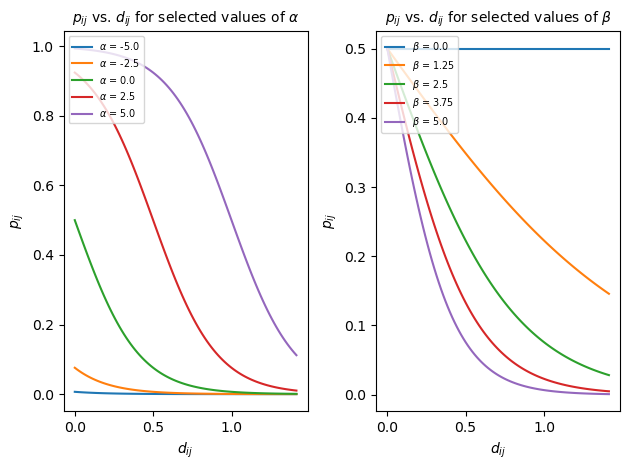

In [58]:
# part a: visualization

# function to use for simulations
def distance_decay_rgg(alpha=0.0, beta=5.0):
    ''' 
    Simulates the relationship between distance and connection probability in a "soft"
    random geometric graph generation model as a function of baseline density and distance weight.

    Args:
    - alpha (float): baseline "inherent propensity" of nodes to connect
    - beta (float): distance weight -- scalar applied to distance

    Returns:
    - results (list): list of probabilities and their associated distances
    '''
    # defining sigmoid function
    sigmoid = lambda x: 1 / (1 + math.exp(-x))

    results = []
    for dist in np.linspace(0, math.sqrt(2), 100): # space of all possible distances
        # apply function
        x = alpha - beta * dist
        results.append((sigmoid(x), dist)) # save both pij and dij for use in plot

    return results

# --- plotting ---

fig, ax = plt.subplots(1,2)

for alpha in np.linspace(-5, 5, 5):
    results = distance_decay_rgg(alpha)
    probs, dist = zip(*results)
    ax[0].plot(dist, probs, label=rf"$\alpha$ = {alpha}")

ax[0].set(title=r"$p_{ij}$ vs. $d_{ij}$ for selected values of $\alpha$", xlabel=r"$d_{ij}$", ylabel=r"$p_{ij}$")
ax[0].title.set_size(10)
ax[0].legend(fontsize='x-small', loc='upper left')

for beta in np.linspace(0, 5, 5):
    results = distance_decay_rgg(beta=beta)
    probs, dist = zip(*results)
    ax[1].plot(dist, probs, label=rf"$\beta$ = {beta}")

ax[1].set(title=r"$p_{ij}$ vs. $d_{ij}$ for selected values of $\beta$", xlabel=r"$d_{ij}$", ylabel=r"$p_{ij}$")
ax[1].title.set_size(10)
ax[1].legend(fontsize='x-small', loc='upper left')

plt.tight_layout()
plt.savefig(r'./imgs/sensitivity_analysis.png')

Small Beta -> # Edges: 3397 | Avg Degree: 22.647 | Avg Distance: 0.454
Large Beta -> # Edges: 281 | Avg Degree: 1.873 | Avg Distance: 0.181


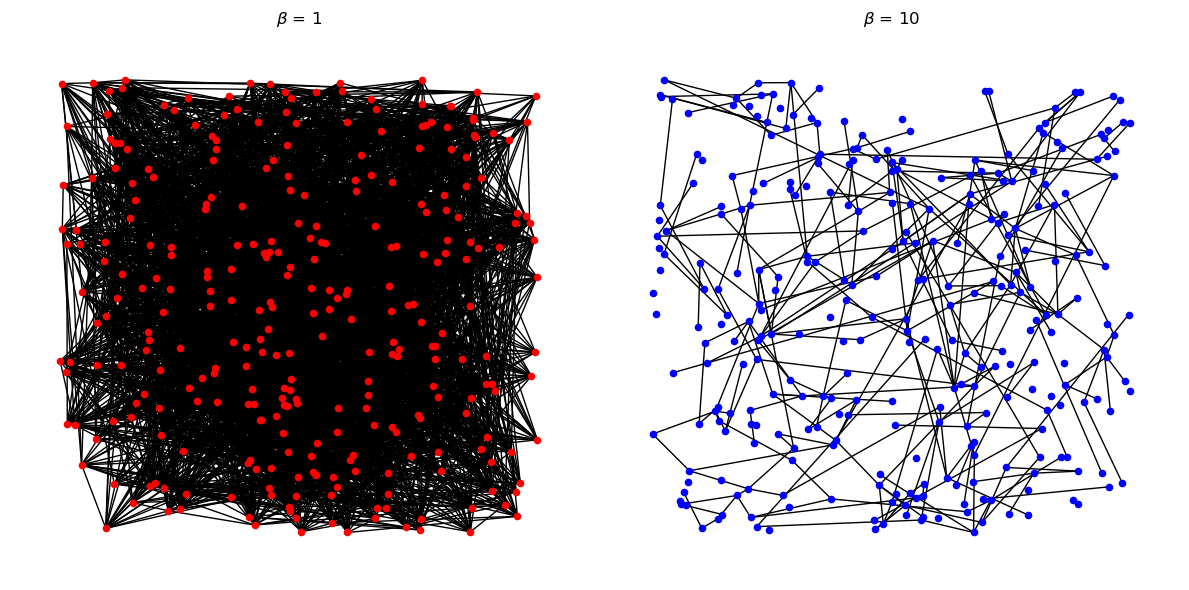

In [60]:
# part b: graph sampling function

def srgg_sampler(alpha=-2.0, beta=1.0):
    ''' 
    Samples soft RGG according to logistic distance-decay model.

    Args:
    - alpha (float): baseline propensity
    - beta (float): distance weight

    Returns:
    - G (nx.Graph): resulting RGG
    '''
    # init nodes in space
    xcoords = np.random.rand(300)
    ycoords = np.random.rand(300)
    nodes = np.column_stack((xcoords, ycoords))

    # building graph
    G = nx.Graph()

    # adding nodes + attributes simultaneously
    for i, (x, y) in enumerate(nodes):
        G.add_node(i, coords=(x, y))

    # defining sigmoid function
    sigmoid = lambda x: 1 / (1 + math.exp(-x))

    # computing distances + probabilities
    indices = range(len(nodes))
    for i, j in itertools.combinations(indices, 2):
        dist = math.dist(nodes[i], nodes[j])
        x = alpha - beta * dist
        prob = sigmoid(x)
        # bernoulli trials for each pair to see if they become edges
        if random.random() < prob:
            G.add_edge(i, j, dist=dist)

    return G

# sampling two graphs
small_beta = srgg_sampler()
large_beta = srgg_sampler(beta=10)

# reporting stats
def statfinder(G, name):
    m = len(G.edges())
    avg_deg = m*2 / len(G.nodes())
    avg_dist = 1 / m * sum(d['dist'] for u, v, d in G.edges(data=True))
    print(f'{name} -> # Edges: {m} | Avg Degree: {avg_deg:.3f} | Avg Distance: {avg_dist:.3f}')

statfinder(small_beta, 'Small Beta')
statfinder(large_beta, 'Large Beta')

# --- visualizing ---

fig, ax = plt.subplots(1,2, figsize=(12, 6))

# retrieving coordinates
pos_sb = nx.get_node_attributes(small_beta, 'coords')
pos_lb = nx.get_node_attributes(large_beta, 'coords')

# drawing
nx.draw(small_beta, pos=pos_sb, ax=ax[0], node_size=20, node_color='red', with_labels=False)
ax[0].set_title(r'$\beta$ = 1')

nx.draw(large_beta, pos=pos_lb, ax=ax[1], node_size=20, node_color='blue', with_labels=False)
ax[1].set_title(r'$\beta$ = 10')

plt.tight_layout()
plt.savefig(r'./imgs/rggs_netviz.png')

# q4

Idaho Falls
# Nodes: 1847 | # Edges: 2666
Tucson
# Nodes: 2781 | # Edges: 4352


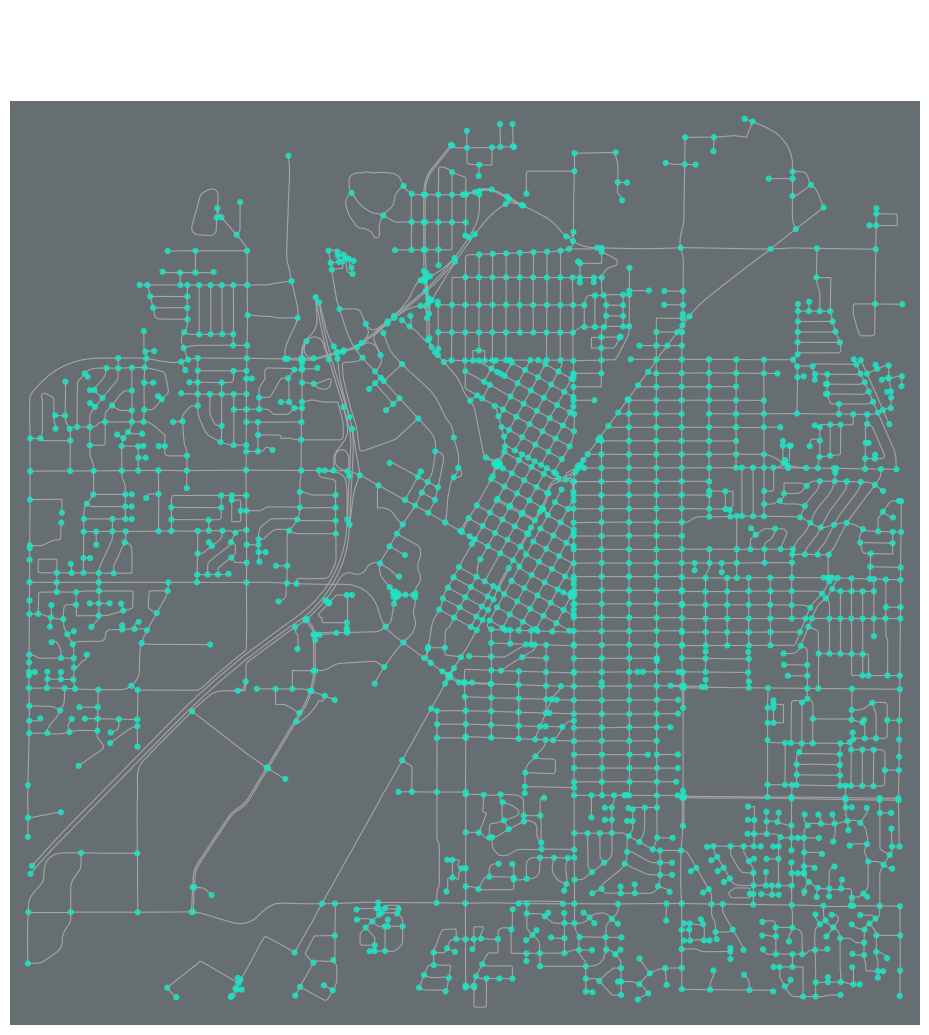

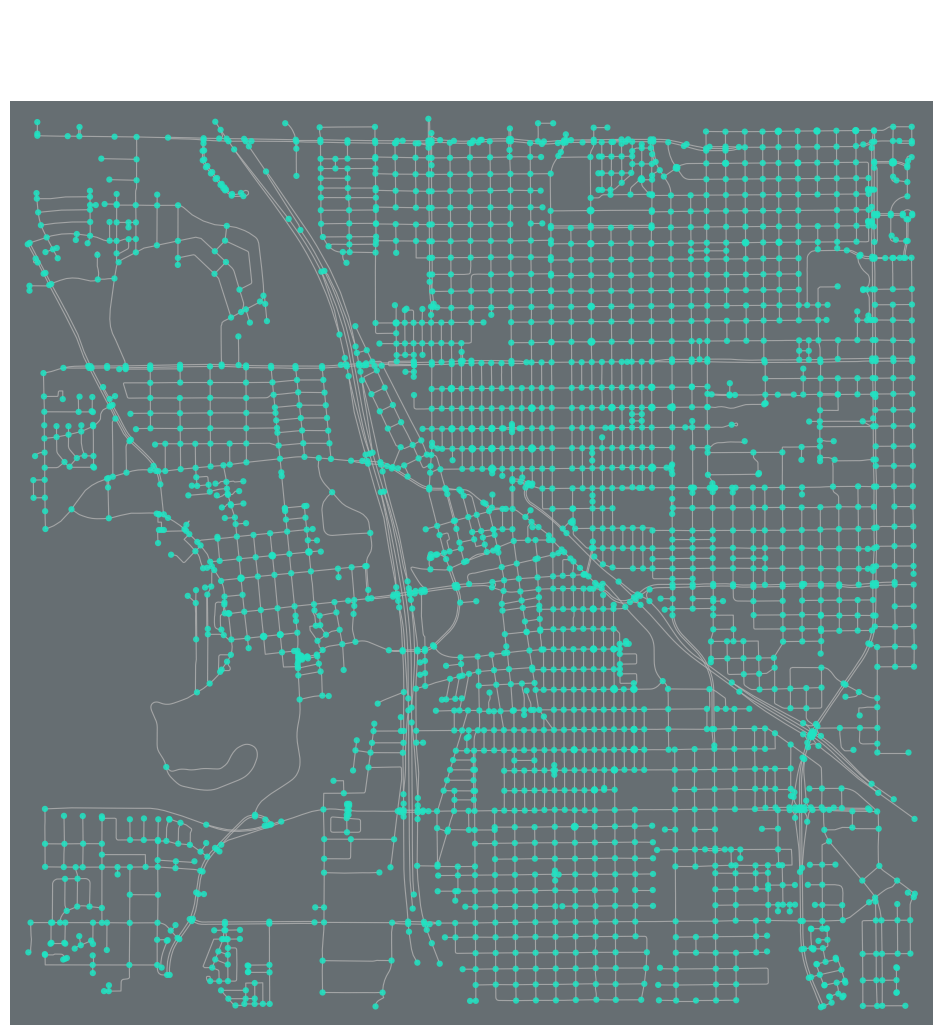

In [106]:
# A-C

# old water tower in IF
IF = ox.graph_from_address("140 S Capital Ave, Idaho Falls, Idaho, USA", dist=3219,
                          network_type="drive")

# converting to undirected and reporting
IF = ox.convert.to_undirected(IF)
IF_simple = nx.Graph(IF)
N = IF_simple.number_of_nodes()
M = IF_simple.number_of_edges()
print(f'Idaho Falls\n# Nodes: {N} | # Edges: {M}')

# visualization
fig, ax = ox.plot_graph(
    IF,
    bgcolor="#0310169A",
    node_size=20,
    node_color="#21e3c3df",
    edge_color=".7",
    edge_linewidth=0.8,
    edge_alpha=0.8,
    figsize=(12, 12),
    dpi=300,
    show=False,
)

ax.set_title(
    "Idaho Falls Street Network\n(2-mi Radius of Old Water Tower)", 
    fontsize=24, 
    color='white', 
    fontweight="bold", 
    pad=20
)
fig.savefig(r'./imgs/if_water_tower.png', dpi=300, bbox_inches='tight')

# --- Tucson ---

T = ox.graph_from_address("Tucson, Arizona, USA", dist=3219,
                          network_type="drive")

T = ox.convert.to_undirected(T)
T_simple = nx.Graph(T)
N = T_simple.number_of_nodes()
M = T_simple.number_of_edges()
print(f'Tucson\n# Nodes: {N} | # Edges: {M}')

fig, ax = ox.plot_graph(
    T,
    bgcolor="#0310169A",
    node_size=20,
    node_color="#21e3c3df",
    edge_color=".7",
    edge_linewidth=0.8,
    edge_alpha=0.8,
    figsize=(12, 12),
    dpi=300,
    show=False,
)

ax.set_title(
    "Tucson Street Network\n(2-mi Radius of Center)", 
    fontsize=24, 
    color='white', 
    fontweight="bold", 
    pad=20
)
fig.savefig(r'./imgs/tucson.png', dpi=300, bbox_inches='tight')


IF features: [9.75984031e-01 1.50052018e+02 5.35282440e-02]
Tucson features: [8.72311465e-01 1.12774926e+02 3.89667985e-02]
Idaho Falls/Tucson Graph Distance: 37.277


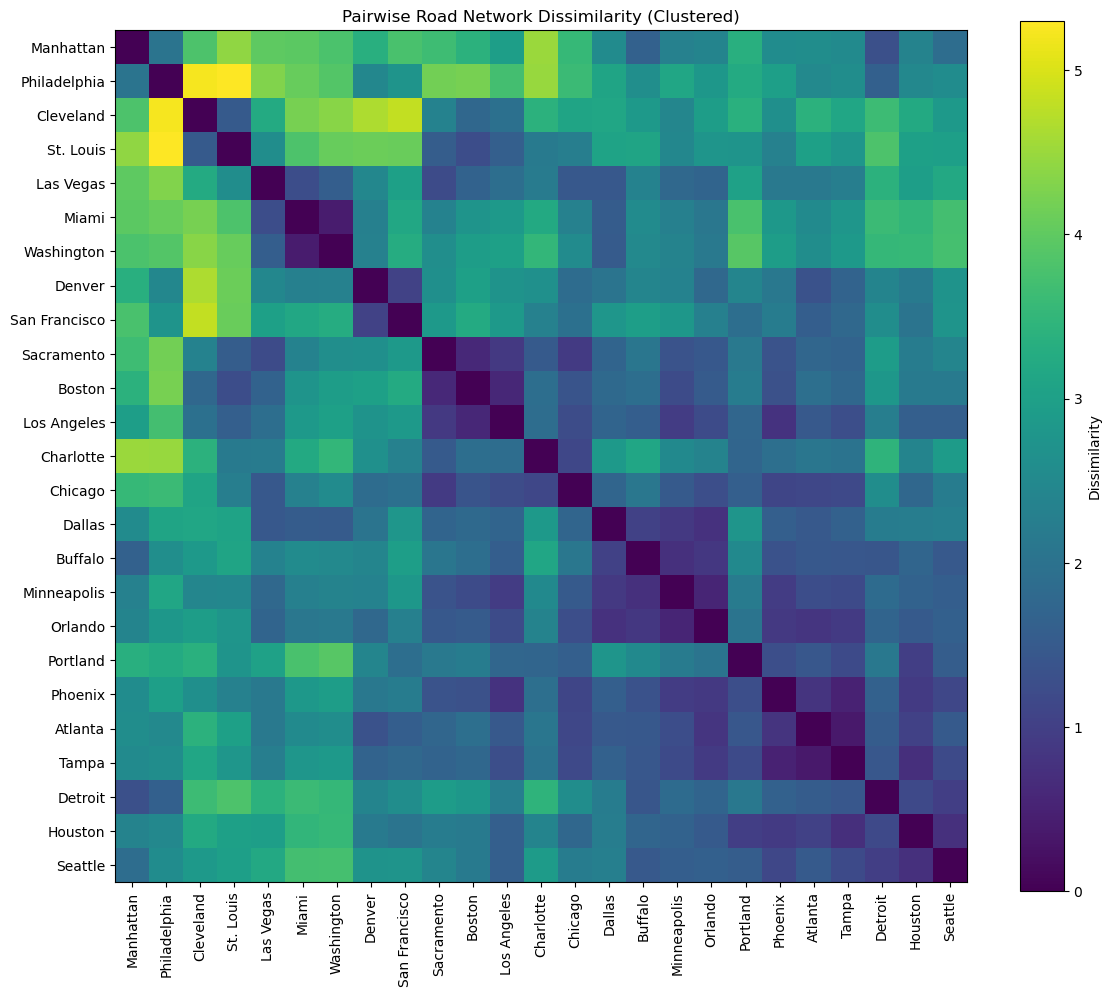

In [100]:
# D-G

# --- descriptor and distance measure ---

def extract_features(G):
    G_simple = nx.Graph(G)
    
    degrees = [d for _, d in G_simple.degree()]
    edge_lengths = [d['length'] for u, v, d in G_simple.edges(data=True)]
    
    f1 = np.std(degrees)
    f2 = np.std(edge_lengths)
    f3 = nx.average_clustering(G_simple)
    
    return np.array([f1, f2, f3])

def dissimilarity(features_G, features_H):
    return np.sqrt(np.sum((features_G - features_H) ** 2))

# --- IF v. Tucson ---

# projecting
IF = ox.project_graph(IF)
T = ox.project_graph(T)

if_gridness = extract_features(IF)
t_gridness = extract_features(T)

print("IF features:", if_gridness)
print("Tucson features:", t_gridness)

distance = dissimilarity(if_gridness, t_gridness)
print(f'Idaho Falls/Tucson Graph Distance: {distance:.3f}')

# --- 25-city comparison (AI-assisted) --

cities = [
    "Atlanta, Georgia, USA",
    "Boston, MA, USA",
    "Buffalo, NY, USA",
    "Charlotte, NC, USA",
    "Chicago, IL, USA",
    "Cleveland, OH, USA",
    "Dallas, TX, USA",
    "Houston, TX, USA",
    "Denver, CO, USA",
    "Detroit, MI, USA",
    "Las Vegas, NV, USA",
    "Los Angeles, CA, USA",
    "Manhattan, NYC, NY, USA",
    "Miami, FL, USA",
    "Minneapolis, MN, USA",
    "Orlando, FL, USA",
    "Philadelphia, PA, USA",
    "Phoenix, AZ, USA",
    "Portland, OR, USA",
    "Sacramento, CA, USA",
    "San Francisco, CA, USA",
    "Seattle, WA, USA",
    "St. Louis, MO, USA",
    "Tampa, FL, USA",
    "Washington, District of Columbia, USA",
]

graphs = {}
for city in cities:
    G = ox.graph_from_address(city, dist=3219, network_type="drive")
    G = ox.project_graph(G)
    G = ox.convert.to_undirected(G)
    graphs[city] = G

# compute features for all cities
all_features = np.array([extract_features(G) for G in graphs.values()])

# z-score normalization
means = all_features.mean(axis=0)
stds = all_features.std(axis=0)
all_features_norm = (all_features - means) / stds

# pairwise distance matrix
n = len(cities)
D = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        D[i, j] = np.sqrt(np.sum((all_features_norm[i] - all_features_norm[j]) ** 2))
        D[j, i] = D[i, j]

# --- visualize ---

# get ordering from hierarchical clustering
Z = linkage(D[np.triu_indices(n, k=1)], method='average')
order = leaves_list(Z)

# reorder matrix and labels
D_sorted = D[np.ix_(order, order)]
short_names = [cities[i].split(",")[0] for i in order]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(D_sorted, cmap="viridis")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_names, rotation=90)
ax.set_yticklabels(short_names)
plt.colorbar(im, ax=ax, label="Dissimilarity")
ax.set_title("Pairwise Road Network Dissimilarity (Clustered)")
plt.tight_layout()
plt.savefig(r'./imgs/similarity_matrix.png')

Function to output similarity between road networks. Measure must:
1. Be greater than or equal to 0
2. Be commutative
3. Show no difference between the same network

parts:
- descriptor to extract features
- distance measure to compare the distance between these descriptors

need to decide features
- what do we care about with road networks?
- path length
- "gridness" via homeogeneity of edge distance